<a href="https://colab.research.google.com/github/Yasser-Baleghi/hands-on-dl-image-processing/blob/master/chapter_09/09_transfer_learning_autoencoders.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Chapter 9: Transfer Learning and Autoencoders

**Author:** Yasser Baleghi

This notebook accompanies Chapter 9 of the book *"Hands-on Deep Learning based Image Processing using Google Colab"*.

---

## 🧭 Why This Chapter Matters

In previous chapters, you learned how to build neural networks and convolutional neural networks from scratch. But in real-world image processing tasks, training a deep network from scratch is often impractical—it requires massive datasets, powerful hardware, and days or weeks of training time.

In this chapter, we introduce **transfer learning**: the practice of leveraging pre-trained models that have already been trained on millions of images. You will see how these models can be adapted to your own image processing tasks with minimal data and training time.

We also introduce **autoencoders**, a type of neural network that learns to compress and reconstruct images, forming the foundation for denoising, anomaly detection, and feature learning.

---

## 📖 How to Use This Notebook

1. **Run cells in order** – Always run cells from top to bottom.
2. **Enable GPU** – Go to **Runtime → Change runtime type → GPU** before running the code.
3. **Upload your own images** – Use the `files.upload()` function.

---

In [ ]:
# ============================================
# 9.1.1 Import Required Libraries
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from google.colab import files
from sklearn.preprocessing import LabelEncoder
import os

%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


In [ ]:
# ============================================
# 9.1.2 Load the Pre-Trained VGG16 Model
# ============================================

# Load VGG16 with pre-trained ImageNet weights
# include_top=True means we load the full model including the classifier
vgg16 = VGG16(weights='imagenet', include_top=True)

# Display the model summary
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Saving Pomegranates.png to Pomegranates.png


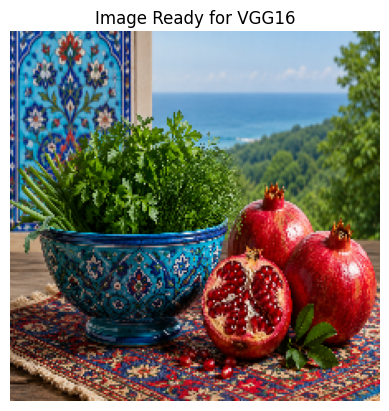

✅ Image preprocessed. Shape: (1, 224, 224, 3)


In [ ]:
# ============================================
# 9.1.3 Upload and Preprocess Your Image
# ============================================

# Upload an image
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# Load and resize the image
image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# VGG16 expects 224x224 images
image_resized = cv2.resize(image_rgb, (224, 224))

# Preprocess the image for VGG16
image_array = np.expand_dims(image_resized, axis=0)
image_preprocessed = preprocess_input(image_array)

# Display the image
plt.imshow(image_resized)
plt.title("Image Ready for VGG16")
plt.axis('off')
plt.show()

print(f"✅ Image preprocessed. Shape: {image_preprocessed.shape}")

In [ ]:
# ============================================
# 9.1.4 Make Predictions with VGG16
# ============================================

# Make predictions
predictions = vgg16.predict(image_preprocessed)

# Decode the predictions
decoded = decode_predictions(predictions, top=5)[0]

# Display the top 5 predictions
print("🔍 Top 5 predictions:")
for i, (imagenet_id, label, probability) in enumerate(decoded):
    print(f"   {i+1}. {label}: {probability*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
🔍 Top 5 predictions:
   1. pomegranate: 28.43%
   2. pitcher: 10.50%
   3. vase: 6.29%
   4. teapot: 3.67%
   5. pot: 3.50%


In [ ]:
# ============================================
# 9.2.2 Load the MNIST Dataset
# ============================================

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to (28, 28, 1) for convolutional autoencoder
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"✅ Training set size: {x_train.shape[0]} images")
print(f"✅ Test set size: {x_test.shape[0]} images")
print(f"✅ Image shape: {x_train.shape[1]} x {x_train.shape[2]} pixels")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Training set size: 60000 images
✅ Test set size: 10000 images
✅ Image shape: 28 x 28 pixels


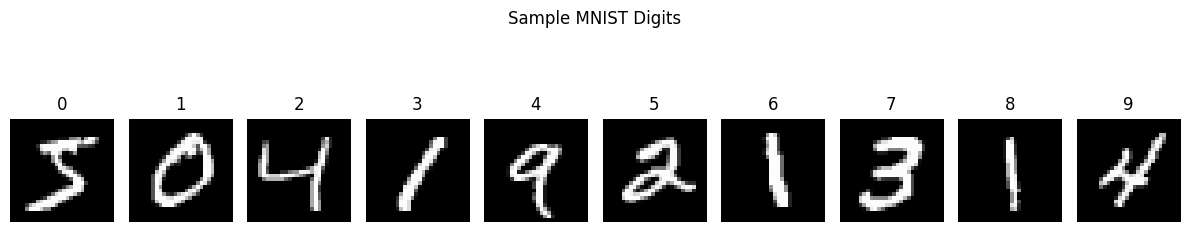

In [ ]:
# ============================================
# 9.2.3 Visualize the MNIST Images
# ============================================

# Display a sample of digits
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    axes[i].imshow(x_train[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'{i}')
plt.suptitle('Sample MNIST Digits')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 9.2.4 Build the Autoencoder
# ============================================

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))

# Encoder: compress the image
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # 4x4

# Decoder: reconstruct the image
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)  # 8x8
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 16x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 32x32
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Create the autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Display the model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# 9.2.4 Build the Autoencoder (Corrected)
# ============================================

from tensorflow.keras.layers import Cropping2D

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))

# Encoder: compress the image
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # 4x4

# Decoder: reconstruct the image
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)  # 8x8
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 16x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 32x32

# Crop from 32x32 to 28x28 to match input shape
x = Cropping2D(cropping=((2, 2), (2, 2)))(x)  # Remove 2 pixels from each side

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Create the autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Display the model summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1951 - val_loss: 0.1376
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1278 - val_loss: 0.1189
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1150 - val_loss: 0.1092
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1082 - val_loss: 0.1047
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1040 - val_loss: 0.1009
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1012 - val_loss: 0.0989
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0991 - val_loss: 0.0968
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0974 - val_loss: 0.0955
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0960 - val_loss: 0.0941
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0950 - val_loss: 0.0943


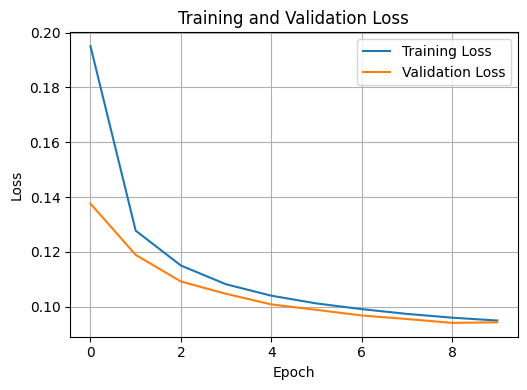

In [ ]:
# ============================================
# 9.2.5 Train the Autoencoder
# ============================================

# Train the autoencoder
history = autoencoder.fit(
    x_train, x_train,  # Input and output are the same
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Plot the training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


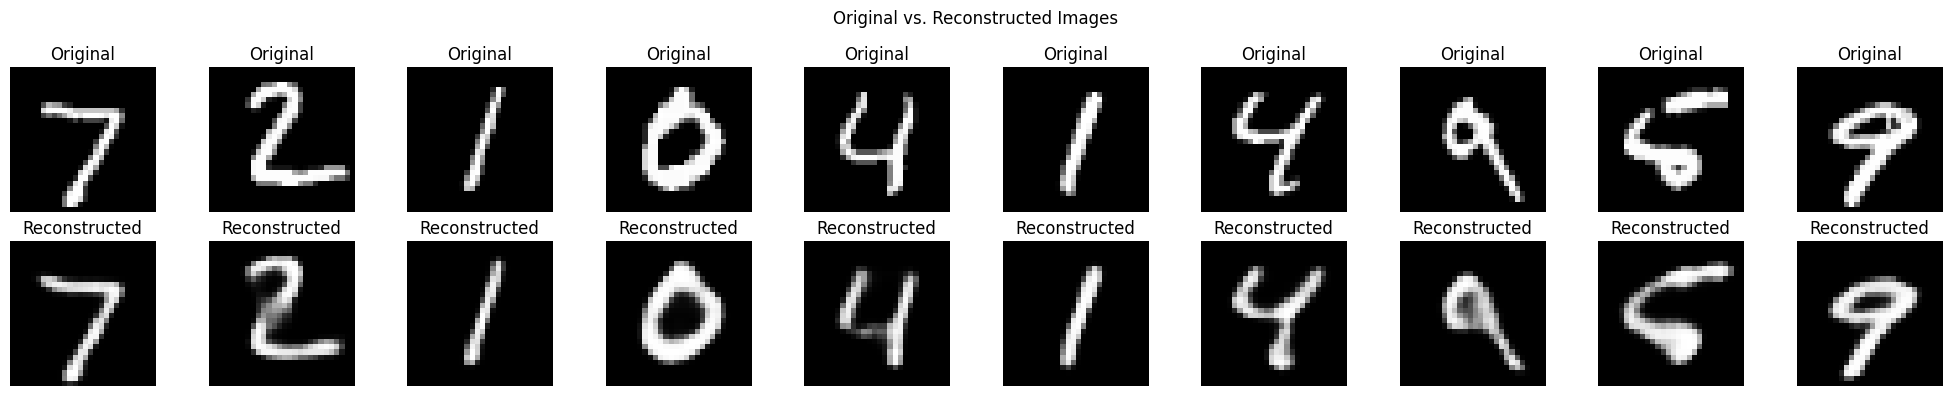

✅ Autoencoder training complete!


In [ ]:
# ============================================
# 9.2.6 Visualize the Reconstructed Images
# ============================================

# Encode and decode some test images
decoded_imgs = autoencoder.predict(x_test[:10])

# Display original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.suptitle('Original vs. Reconstructed Images')
plt.tight_layout()
plt.show()

print("✅ Autoencoder training complete!")

In [ ]:
# ============================================
# 9.3.1 Extract Features from the Encoder
# ============================================

# Extract the encoder part of the autoencoder
encoder = Model(input_img, encoded)

# Encode the test images
encoded_imgs = encoder.predict(x_test)

print(f"Shape of encoded images: {encoded_imgs.shape}")

# Flatten for visualization
encoded_flattened = encoded_imgs.reshape(encoded_imgs.shape[0], -1)
print(f"Flattened shape: {encoded_flattened.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shape of encoded images: (10000, 4, 4, 8)
Flattened shape: (10000, 128)


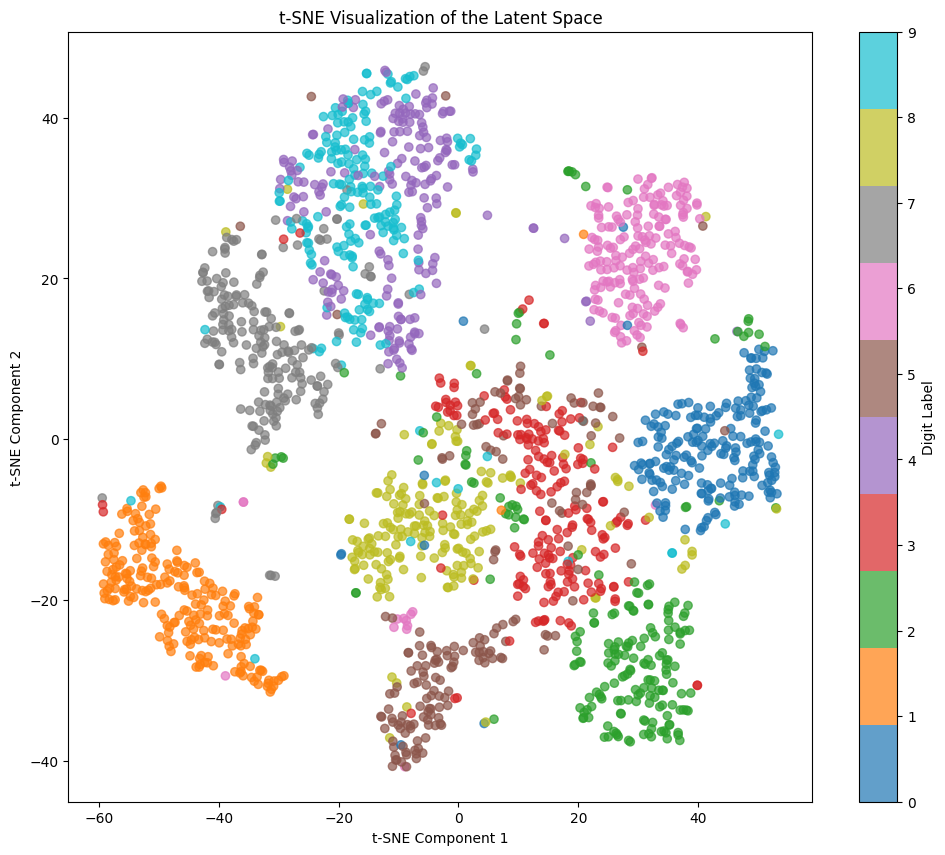

In [ ]:
# ============================================
# 9.3.2 Visualize the Latent Space (Corrected)
# ============================================

from sklearn.manifold import TSNE
import seaborn as sns

# Use only 2000 samples for visualization (to keep it fast)
sample_indices = np.random.choice(len(x_test), 2000, replace=False)
sample_encoded = encoded_flattened[sample_indices]

# Use integer labels directly (y_test is 1D, no argmax needed)
sample_labels = y_test[sample_indices].flatten()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(sample_encoded)

# Plot the t-SNE results
plt.figure(figsize=(12, 10))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                     c=sample_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title('t-SNE Visualization of the Latent Space')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [ ]:
# ============================================
# 9.3.3 Use Autoencoder Features for Classification (Fixed)
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Prepare training data
train_encoded = encoder.predict(x_train).reshape(x_train.shape[0], -1)
test_encoded = encoder.predict(x_test).reshape(x_test.shape[0], -1)

# Scale the encoded features (improves convergence)
scaler = StandardScaler()
train_encoded_scaled = scaler.fit_transform(train_encoded)
test_encoded_scaled = scaler.transform(test_encoded)

# Train a classifier on the scaled encoded features
clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(train_encoded_scaled, y_train)

# Evaluate the classifier
y_pred = clf.predict(test_encoded_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification accuracy on encoded features: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification accuracy on encoded features: 0.9747

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
# ============================================
# 9.3.4 Compare with Raw Pixel Classification
# ============================================

# Classify using raw pixels
clf_raw = LogisticRegression(max_iter=1000, random_state=42)

# Flatten the raw images
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

clf_raw.fit(x_train_flat, y_train)
y_pred_raw = clf_raw.predict(x_test_flat)
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print(f"Classification accuracy (raw pixels): {accuracy_raw:.4f}")
print(f"Classification accuracy (autoencoder features): {accuracy:.4f}")

Classification accuracy (raw pixels): 0.9259
Classification accuracy (autoencoder features): 0.9747


In [ ]:
# ============================================
# 9.7.4 Feature Extraction Phase
# ============================================

# Load CIFAR-10 as a stand-in for a custom dataset
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Use only a subset for faster training
x_train = x_train[:2000]
y_train = y_train[:2000]
x_test = x_test[:500]
y_test = y_test[:500]

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Resize images to 224x224 for VGG16
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

def resize_images(images, target_size=(224, 224)):
    resized = []
    for img in images:
        img_pil = array_to_img(img)
        img_resized = img_pil.resize(target_size)
        resized.append(img_to_array(img_resized))
    return np.array(resized)

x_train_resized = resize_images(x_train)
x_test_resized = resize_images(x_test)

print(f"✅ Resized training set: {x_train_resized.shape}")
print(f"✅ Resized test set: {x_test_resized.shape}")

# Load VGG16 without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Create the complete model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with frozen base
history_extraction = model.fit(
    x_train_resized, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_resized, y_test),
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test accuracy after feature extraction: {test_acc:.4f}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1908s 11us/step
✅ Resized training set: (2000, 224, 224, 3)
✅ Resized test set: (500, 224, 224, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 487ms/step - accuracy: 0.4375 - loss: 1.7454 - val_accuracy: 0.5880 - val_loss: 1.1481
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.7255 - loss: 0.7991 - val_accuracy: 0.6460 - val_loss: 0.9904
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.8110 - loss: 0.5689 - val_accuracy: 0.6800 - val_loss: 0.9287
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.8735 - loss: 0.3957 - val_accuracy: 0.7080 - val_loss: 0.9336
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.9075 - loss: 0.3022 - val_accuracy: 0.7100 - val_loss: 0.8449
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.9355 - loss: 0.2160 - val_accuracy: 0.7260 - val_loss: 0.8501
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================
# 9.7.5 Fine-Tuning Phase
# ============================================

# Unfreeze the top layers
base_model.trainable = True

# Choose which layers to unfreeze (from block5 onward)
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Fine-tuning ready.")

# Fine-tune the model
history_finetune = model.fit(
    x_train_resized, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_resized, y_test),
    verbose=1
)

# Evaluate
test_loss_ft, test_acc_ft = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test accuracy after feature extraction: {test_acc:.4f}")
print(f"Test accuracy after fine-tuning: {test_acc_ft:.4f}")
print(f"Improvement: {(test_acc_ft - test_acc)*100:.2f}%")

✅ Fine-tuning ready.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 293ms/step - accuracy: 0.9980 - loss: 0.0312 - val_accuracy: 0.7380 - val_loss: 1.0109
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.7400 - val_loss: 1.0709
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.7340 - val_loss: 1.1074
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.7400 - val_loss: 1.1317
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 236ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.7300 - val_loss: 1.1757
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 240ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.7380 - val_loss: 1.1799
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - accuracy: 1.0000 - loss: 8.5844e-04 - val_accuracy: 0.7340 - val_loss: 1.2145
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 1.0000 